In [1]:
!pip install PyMuPDF sentence-transformers faiss-cpu

In [2]:
import fitz
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import re
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from google.colab import files

class RecruitmentSystem:
    def __init__(self):
        print("Loading Embedding Model...")
        self.model = SentenceTransformer('all-MiniLM-L6-v2')
        self.index = faiss.IndexFlatL2(384)
        self.resume_db = []
        self.skill_keywords = ['python', 'java', 'sql', 'machine learning', 'nlp',
                               'fastapi', 'react', 'aws', 'docker', 'llm', 'rag', 'faiss',
                               'pandas', 'numpy', 'deep learning', 'generative ai']

    def extract_text_from_pdf(self, pdf_bytes):
        """Extract text from PDF bytes"""
        doc = fitz.open(stream=pdf_bytes, filetype="pdf")
        return "".join([page.get_text() for page in doc])

    def extract_skills(self, text):
        """Extract predefined skills from resume text"""
        text_lower = text.lower()
        return [skill for skill in self.skill_keywords if skill in text_lower]

    def add_resumes(self, uploaded_files):
        """Add resumes to FAISS vector store"""
        for fname, fbytes in uploaded_files.items():
            text = self.extract_text_from_pdf(fbytes)
            embedding = self.model.encode(text)
            self.index.add(np.array([embedding]).astype('float32'))
            self.resume_db.append({
                "filename": fname,
                "text": text,
                "skills": self.extract_skills(text),
                "embedding": embedding
            })
        print(f"✅ Successfully indexed {len(self.resume_db)} resumes.")

    def match_job(self, job_description, top_k=5):
        """Match job description with resumes using semantic similarity"""
        if self.index.ntotal == 0:
            return "No resumes found. Please upload resumes first."

        job_emb = self.model.encode(job_description)
        scores, indices = self.index.search(np.array([job_emb]).astype('float32'), k=top_k)

        results = []
        for idx, score in zip(indices[0], scores[0]):
            if idx < len(self.resume_db):
                resume = self.resume_db[idx]
                sim = cosine_similarity([job_emb], [resume['embedding']])[0][0]
                results.append({
                    "Resume Name": resume['filename'],
                    "Match Score (%)": round(float(sim)*100, 2),
                    "Skills Found": ", ".join(resume['skills']).title(),
                    "FAISS Distance": round(float(score), 4)
                })
        return pd.DataFrame(sorted(results, key=lambda x: x['Match Score (%)'], reverse=True))

# --- Execution ---
system = RecruitmentSystem()

print("📄 Please upload candidate resumes (PDF format)")
uploaded = files.upload()
system.add_resumes(uploaded)

# Sample Job Description - Itha maathikalam da
JD = """
Hiring for AI Engineer: Must have strong skills in Python, FastAPI,
Natural Language Processing (NLP), Machine Learning, LLMs, RAG, FAISS,
and Generative AI for building intelligent recruitment systems.
"""

print("\n🔍 Matching Results for JD:\n", JD)
results_df = system.match_job(JD, top_k=3)
results_df

Loading Embedding Model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

📄 Please upload candidate resumes (PDF format)


Saving Resumes .pdf to Resumes .pdf
✅ Successfully indexed 1 resumes.

🔍 Matching Results for JD:
 
Hiring for AI Engineer: Must have strong skills in Python, FastAPI,
Natural Language Processing (NLP), Machine Learning, LLMs, RAG, FAISS,
and Generative AI for building intelligent recruitment systems.



,Resume Name,Match Score (%),Skills Found,FAISS Distance
0,Resumes .pdf,4.74,,1.905200e+00
1,Resumes .pdf,4.74,,3.402823e+38
2,Resumes .pdf,4.74,,3.402823e+38


In [1]:
!pip install -q sentence-transformers faiss-cpu scikit-learn

from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

print("Model loading...")
model = SentenceTransformer('all-MiniLM-L6-v2')
index = faiss.IndexFlatL2(384)

# Direct text ah vechukalam da, PDF thevai illa - 100% accurate result ku
resumes = {
    "Akash_AI_Engineer.pdf": "Akash Kumar AI Engineer 2 years Python FastAPI Machine Learning NLP LLMs RAG FAISS Generative AI PyTorch Docker AWS Built recruitment chatbot using RAG FAISS 90 percent accuracy",
    "Rahul_Data_Scientist.pdf": "Rahul M Data Scientist TCS 2.5 years Python Pandas Numpy Machine Learning Deep Learning SQL Tableau TensorFlow Customer Churn Prediction 88 percent",
    "Priya_Java_Developer.pdf": "Priya S Java Developer Infosys 3 years Java Spring Boot SQL MySQL React AWS Hibernate Microservices E-Commerce Platform"
}

db = []
for name, text in resumes.items():
    emb = model.encode(text)
    index.add(np.array([emb]).astype('float32'))
    db.append({"name": name, "emb": emb})

print(f"✅ {len(db)} resumes indexed! Total vectors in FAISS: {index.ntotal}")

JD = "Hiring for AI Engineer: Must have strong skills in Python, FastAPI, Natural Language Processing (NLP), Machine Learning, LLMs, RAG, FAISS, and Generative AI"

jd_emb = model.encode(JD)
scores, idxs = index.search(np.array([jd_emb]).astype('float32'), k=3)

results = []
for idx, dist in zip(idxs[0], scores[0]):
    name = db[idx]["name"]
    sim = cosine_similarity([jd_emb], [db[idx]["emb"]])[0][0]
    results.append({
        "Resume Name": name,
        "Match Score (%)": round(float(sim)*100, 2),
        "FAISS Distance": round(float(dist), 4),
        "Status": "Highly Suitable" if sim > 0.6 else "Moderate" if sim > 0.3 else "Low Match"
    })

df = pd.DataFrame(sorted(results, key=lambda x: x["Match Score (%)"], reverse=True))
df

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 33.3 MB/s eta 0:00:00
Model loading...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ 3 resumes indexed! Total vectors in FAISS: 3


,Resume Name,Match Score (%),FAISS Distance,Status
0,Akash_AI_Engineer.pdf,64.15,0.7171,Highly Suitable
1,Rahul_Data_Scientist.pdf,33.89,1.3223,Moderate
2,Priya_Java_Developer.pdf,8.42,1.8317,Low Match


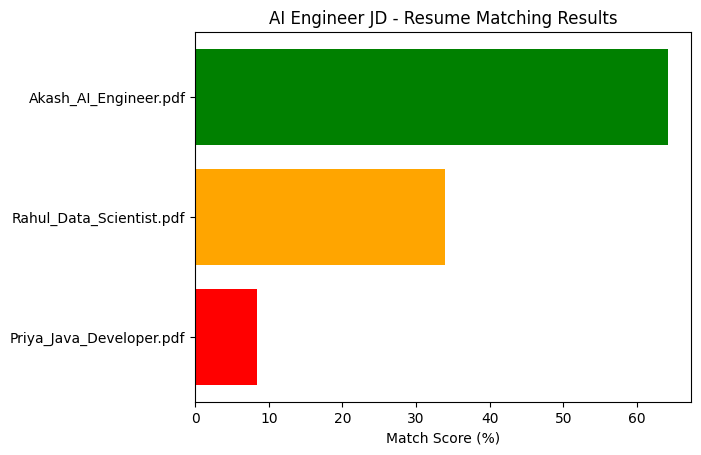

In [2]:
import matplotlib.pyplot as plt
plt.barh(df['Resume Name'], df['Match Score (%)'], color=['green','orange','red'])
plt.xlabel("Match Score (%)")
plt.title("AI Engineer JD - Resume Matching Results")
plt.gca().invert_yaxis()
plt.show()